In [2]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/telco_churn_clean.csv')
print("Clean data loaded:", df.shape)

Clean data loaded: (7043, 29)


In [4]:
churn_rate = df['churn'].mean() * 100
total_customers = len(df)
churned = df['churn'].sum()
retained = total_customers - churned

print(f"Total customers: {total_customers}")
print(f"Churned: {churned}")
print(f"Retained: {retained}")
print(f"Churn rate: {churn_rate:.2f}%")

Total customers: 7043
Churned: 1869
Retained: 5174
Churn rate: 26.54%


In [5]:
contract_churn = df.groupby('contract')['churn'].agg(['mean', 'sum', 'count'])
contract_churn['churn_rate_%'] = (contract_churn['mean'] * 100).round(2)
contract_churn.columns = ['churn_rate', 'churned_customers', 'total_customers', 'churn_rate_%']
print("Churn by contract type:")
print(contract_churn)

Churn by contract type:
                churn_rate  churned_customers  total_customers  churn_rate_%
contract                                                                    
Month-to-month    0.427097               1655             3875         42.71
One year          0.112695                166             1473         11.27
Two year          0.028319                 48             1695          2.83


In [6]:
tenure_analysis = df.groupby('churn')['tenure'].agg(['mean', 'median', 'min', 'max'])
tenure_analysis.index = ['Retained', 'Churned']
print("Tenure analysis:")
print(tenure_analysis.round(2))

Tenure analysis:
           mean  median  min  max
Retained  37.57    38.0    0   72
Churned   17.98    10.0    1   72


In [7]:
high_risk_df = df[df['is_high_risk'] == 1]
revenue_at_risk = high_risk_df['monthlycharges'].sum()
total_revenue = df['monthlycharges'].sum()
percentage_at_risk = (revenue_at_risk / total_revenue) * 100

print(f"High risk customers: {len(high_risk_df)}")
print(f"Monthly revenue at risk: ${revenue_at_risk:,.2f}")
print(f"Total monthly revenue: ${total_revenue:,.2f}")
print(f"Percentage at risk: {percentage_at_risk:.2f}%")

High risk customers: 521
Monthly revenue at risk: $42,489.75
Total monthly revenue: $456,116.60
Percentage at risk: 9.32%


In [8]:
payment_churn = df.groupby('paymentmethod')['churn'].mean() * 100
payment_churn = payment_churn.sort_values(ascending=False)
print("Churn rate by payment method:")
print(payment_churn.round(2))

Churn rate by payment method:
paymentmethod
Electronic check             45.29
Mailed check                 19.11
Bank transfer (automatic)    16.71
Credit card (automatic)      15.24
Name: churn, dtype: float64


In [9]:
dependents_churn = df.groupby('dependents')['churn'].mean() * 100
dependents_churn.index = ['No Dependents', 'Has Dependents']
print("Churn by dependents:")
print(dependents_churn.round(2))

Churn by dependents:
No Dependents     31.28
Has Dependents    15.45
Name: churn, dtype: float64


In [10]:
revenue_by_internet = df.groupby('internetservice')['monthlycharges'].agg(['sum', 'mean', 'count'])
revenue_by_internet.columns = ['total_revenue', 'avg_charge', 'customer_count']
print("Revenue by internet service:")
print(revenue_by_internet.round(2))

Revenue by internet service:
                 total_revenue  avg_charge  customer_count
internetservice                                           
DSL                  140665.35       58.10            2421
Fiber optic          283284.40       91.50            3096
No                    32166.85       21.08            1526


In [11]:
at_risk_high_value = df[
    (df['is_high_risk'] == 1) &
    (df['churn'] == 0)
].sort_values('total_value', ascending=False)

print("Top 10 high value customers still at risk:")
print(at_risk_high_value[['customerid', 'tenure', 'monthlycharges',
                           'total_value', 'contract']].head(10))

Top 10 high value customers still at risk:
      customerid  tenure  monthlycharges  total_value        contract
2387  6734-GMPVK       5          105.30       526.50  Month-to-month
6696  4566-NECEV       5           96.55       482.75  Month-to-month
6804  8212-DJRCH       5           90.35       451.75  Month-to-month
5970  4853-OITSN       5           89.15       445.75  Month-to-month
4204  4395-PZMSN       5           85.55       427.75  Month-to-month
2288  2135-DQWAQ       5           85.30       426.50  Month-to-month
1022  8242-SOQUO       5           84.70       423.50  Month-to-month
2350  8739-XNIKG       5           84.00       420.00  Month-to-month
1710  6435-SRWBJ       5           82.75       413.75  Month-to-month
727   6786-OBWQR       5           80.85       404.25  Month-to-month


In [12]:
senior_churn = df.groupby('seniorcitizen')['churn'].agg(['mean', 'sum', 'count'])
senior_churn['churn_rate_%'] = (senior_churn['mean'] * 100).round(2)
senior_churn.index = ['Non-Senior', 'Senior']
print("Churn by senior citizen status:")
print(senior_churn)

Churn by senior citizen status:
                mean   sum  count  churn_rate_%
Non-Senior  0.236062  1393   5901         23.61
Senior      0.416813   476   1142         41.68


In [13]:
df['tenure_group'] = pd.cut(df['tenure'],
    bins=[0, 6, 12, 24, 48, 72],
    labels=['0-6 months', '6-12 months', '12-24 months',
            '24-48 months', '48-72 months'])

tenure_group_churn = df.groupby('tenure_group')['churn'].mean() * 100
print("Churn rate by tenure group:")
print(tenure_group_churn.round(2))

Churn rate by tenure group:
tenure_group
0-6 months      53.33
6-12 months     35.89
12-24 months    28.71
24-48 months    20.39
48-72 months     9.51
Name: churn, dtype: float64


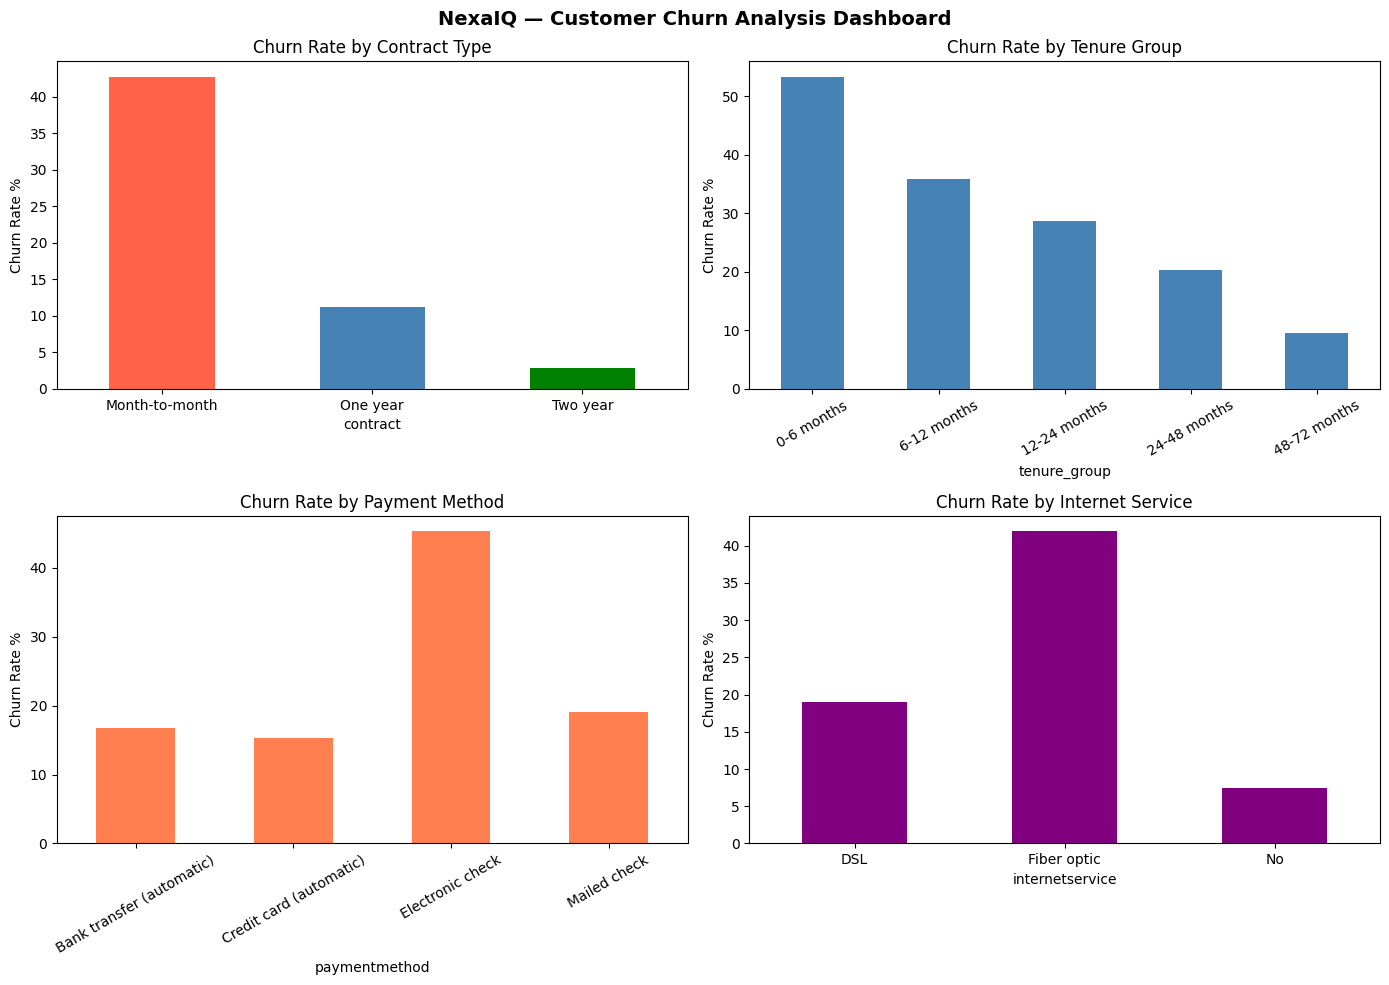

Dashboard chart saved


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.groupby('contract')['churn'].mean().mul(100).plot(
    kind='bar', ax=axes[0,0], color=['tomato', 'steelblue', 'green'])
axes[0,0].set_title('Churn Rate by Contract Type')
axes[0,0].set_ylabel('Churn Rate %')
axes[0,0].tick_params(axis='x', rotation=0)

tenure_group_churn.plot(
    kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Churn Rate by Tenure Group')
axes[0,1].set_ylabel('Churn Rate %')
axes[0,1].tick_params(axis='x', rotation=30)

df.groupby('paymentmethod')['churn'].mean().mul(100).plot(
    kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Churn Rate by Payment Method')
axes[1,0].set_ylabel('Churn Rate %')
axes[1,0].tick_params(axis='x', rotation=30)

df.groupby('internetservice')['churn'].mean().mul(100).plot(
    kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Churn Rate by Internet Service')
axes[1,1].set_ylabel('Churn Rate %')
axes[1,1].tick_params(axis='x', rotation=0)

plt.suptitle('NexaIQ — Customer Churn Analysis Dashboard',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/day04_churn_dashboard.png')
plt.show()
print("Dashboard chart saved")